<a href="https://colab.research.google.com/github/Deepika-bysani2006/AI-Career-Companion-Agent-for-Internship-Matching-and-Interview-Preparation./blob/main/DoctorVisitsAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

Read the dataset


In [4]:
df=pd.read_csv("/content/DoctorVisits.csv")
print(df.head(15))

    Unnamed: 0  visits  gender   age  income  illness  reduced  health  \
0            1       1  female  0.19    0.55        1        4       1   
1            2       1  female  0.19    0.45        1        2       1   
2            3       1    male  0.19    0.90        3        0       0   
3            4       1    male  0.19    0.15        1        0       0   
4            5       1    male  0.19    0.45        2        5       1   
5            6       1  female  0.19    0.35        5        1       9   
6            7       1  female  0.19    0.55        4        0       2   
7            8       1  female  0.19    0.15        3        0       6   
8            9       1  female  0.19    0.65        2        0       5   
9           10       1    male  0.19    0.15        1        0       0   
10          11       1    male  0.19    0.45        1        0       0   
11          12       1    male  0.19    0.25        2        0       2   
12          13       2    male  0.19  

In [7]:
df.head(15)

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no
5,6,1,female,0.19,0.35,5,1,9,no,no,no,yes,no
6,7,1,female,0.19,0.55,4,0,2,no,no,no,no,no
7,8,1,female,0.19,0.15,3,0,6,no,no,no,no,no
8,9,1,female,0.19,0.65,2,0,5,yes,no,no,no,no
9,10,1,male,0.19,0.15,1,0,0,yes,no,no,no,no


Display complete information about data set

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


Find out the total number of people based on their count of ill ness


In [11]:
df["illness"].value_counts()

,count
illness,
1,1638
0,1554
2,946
3,542
4,274
5,236


In [12]:
df["gender"].value_counts()

,count
gender,
female,2702
male,2488


Visualize and analyze the maximum,minimum and median incomes

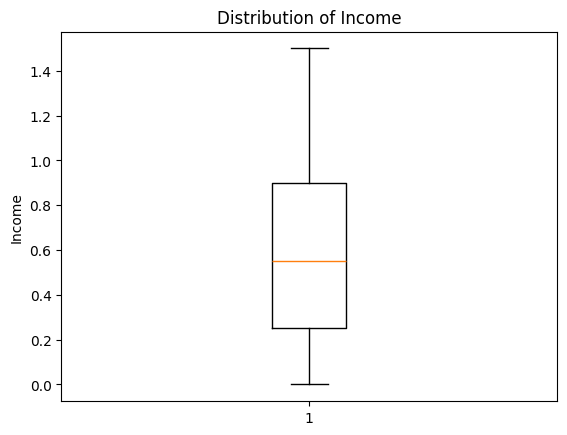

In [18]:
y=list(df.income)
plt.boxplot(y)
plt.title('Distribution of Income')
plt.ylabel('Income')
plt.show()

find out the number of days of reduced activity of male and female  seperately due to illness


In [19]:
df.groupby(['gender', 'illness'])['reduced'].mean()

gender  illness
female  0          0.042710
        1          1.083933
        2          1.015066
        3          1.246246
        4          1.928144
        5          2.702532
male    0          0.057143
        1          0.781095
        2          1.067470
        3          1.511962
        4          1.710280
        5          2.782051
Name: reduced, dtype: float64

Visualize is there any missing values in the data set based on heat map


<Axes: >

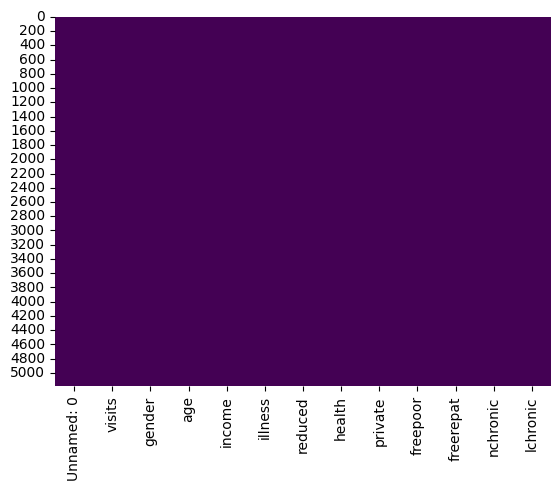

In [21]:
#missing values
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')

find out the corelation blw variables in the given dataset correlation blw different variables



<Axes: >

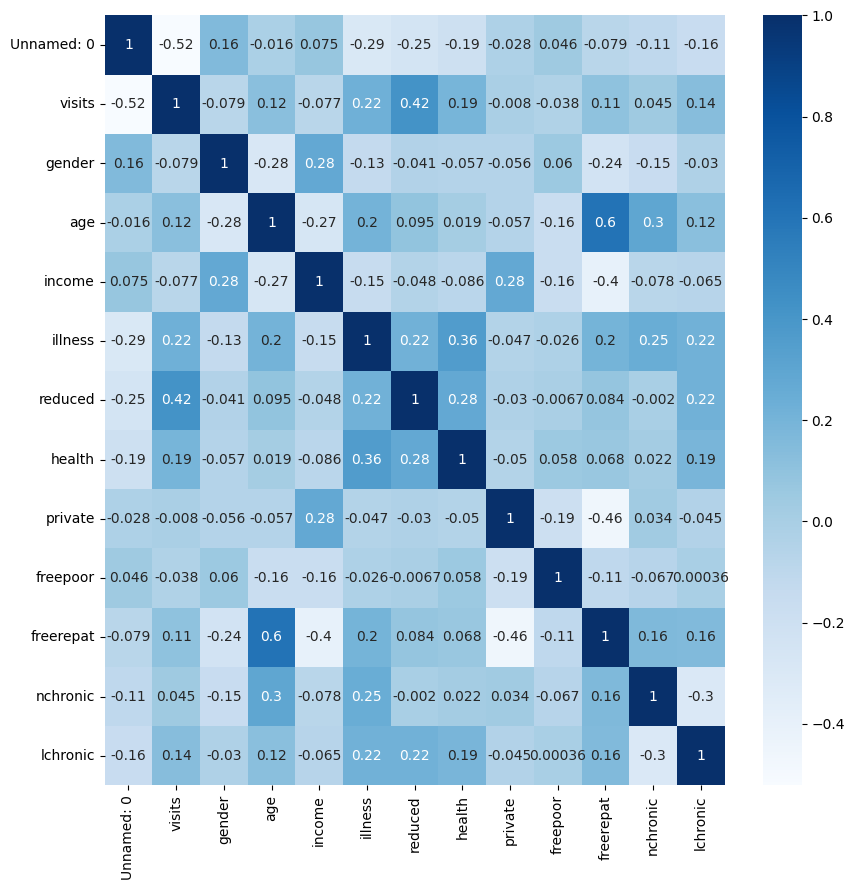

In [25]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),cbar=True,annot=True,cmap='Blues')

Analyze how income of patient affects the no of visits to the hospital
visits


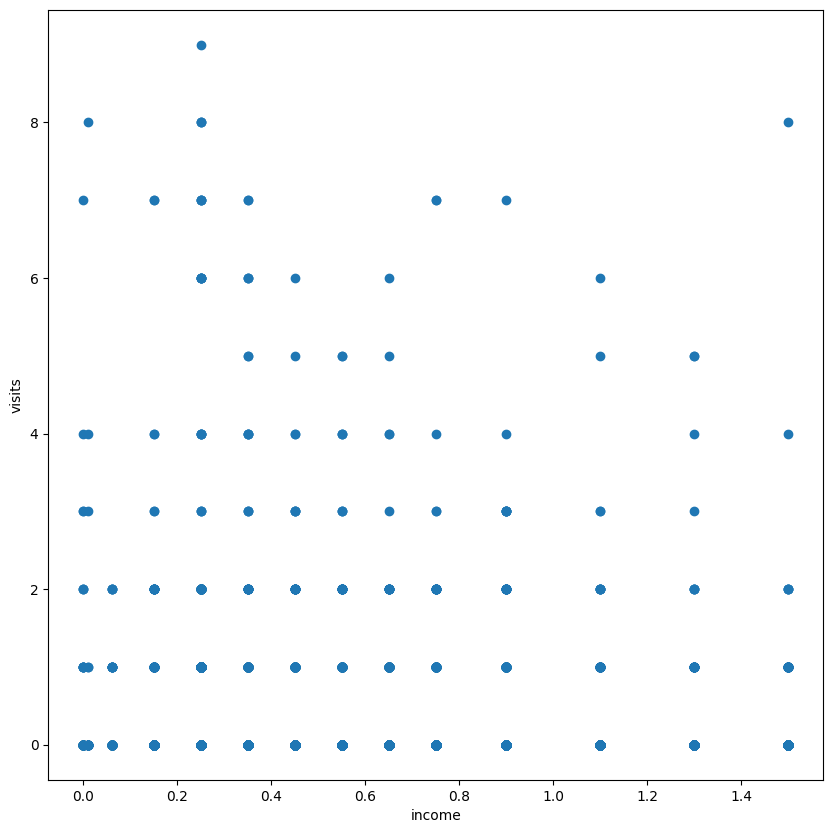

In [26]:
plt.figure(figsize=(10,10))
plt.scatter(x=df['income'],y=df['visits'])
plt.xlabel('income')
plt.ylabel('visits')
plt.show()

count and visualize the no of males and females affected bt illness

<Axes: xlabel='gender', ylabel='Count'>

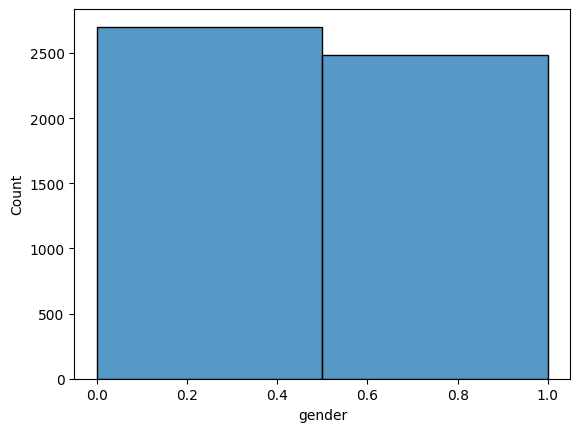

In [27]:
sns.histplot(df.gender,bins=2)

Visualize the percentage of people getting government health insurance due to low income, due to old age, and the percentage of people having private health insurance

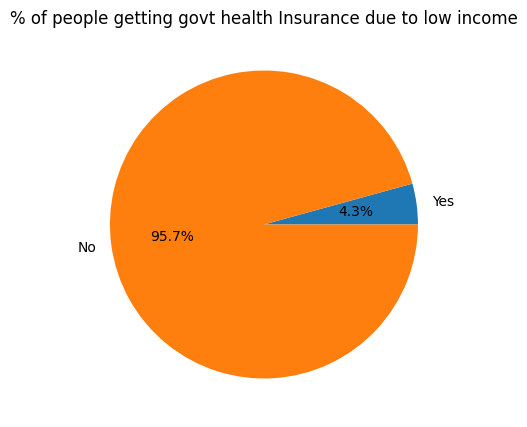

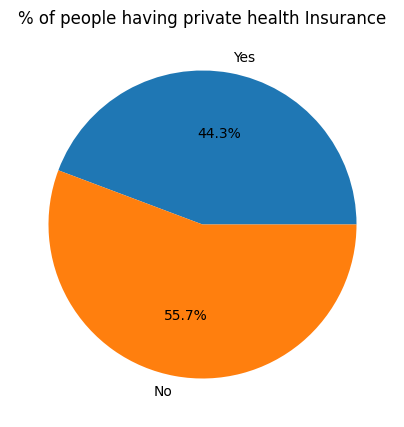

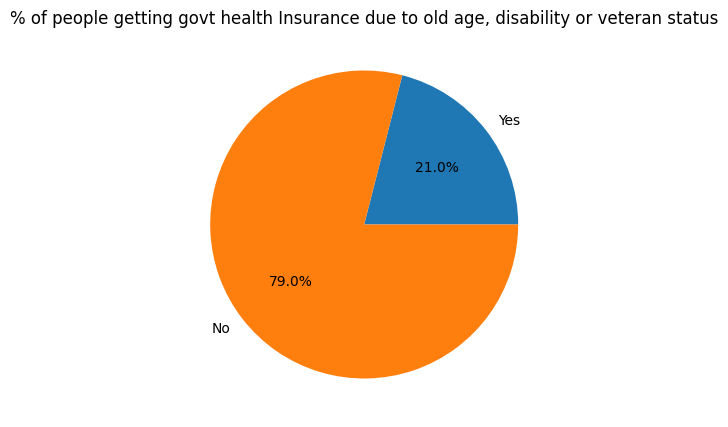

In [36]:
import matplotlib.pyplot as plt

label = ['Yes', 'No']

# % of people getting govt Insurance due to low income
yes = (df['freepoor'] == 1).sum()
no = (df['freepoor'] == 0).sum()
x = [yes, no]

plt.figure(figsize=(5,5))
plt.pie(x, labels=label, autopct='%1.1f%%')
plt.title("% of people getting govt health Insurance due to low income")
plt.show()


# % of people having private Insurance
yes = (df['private'] == 1).sum()
no = (df['private'] == 0).sum()
x = [yes, no]

plt.figure(figsize=(5,5))
plt.pie(x, labels=label, autopct='%1.1f%%')
plt.title("% of people having private health Insurance")
plt.show()


# % of people getting govt Insurance due to old age,
# disability or veteran status
yes = (df['freerepat'] == 1).sum()
no = (df['freerepat'] == 0).sum()
x = [yes, no]

plt.figure(figsize=(5,5))
plt.pie(x, labels=label, autopct='%1.1f%%')
plt.title("% of people getting govt health Insurance due to old age, disability or veteran status")
plt.show()

Analysis of Reduced Activity Days Due to Illness Based on Gender

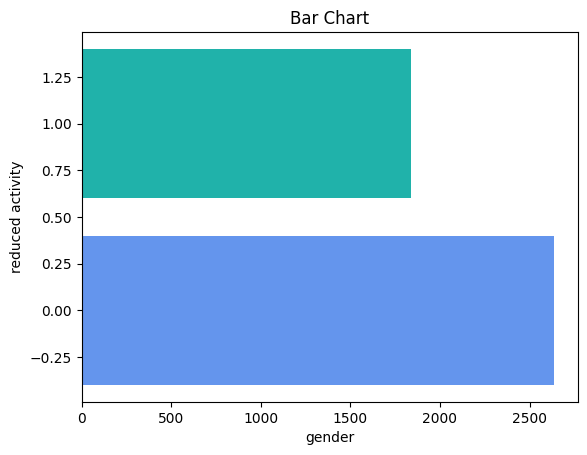

In [38]:
df1 = df.groupby('gender')['reduced'].sum().to_frame().reset_index()

# Creating the bar chart
plt.barh(df1['gender'], df1['reduced'], color=['cornflowerblue', 'lightseagreen'])

# Adding the aesthetics
plt.title('Bar Chart')
plt.xlabel('gender')
plt.ylabel('reduced activity')

# Show the plot
plt.show()